# Photon Subtraction in Graph State
2026\. 05\. 19.  Make the pseudo code

## 1. Set the graph state

##### Initial parameters, modules and functions

In [166]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
# Graph: paper-style 6-node graph, labels 1-6 1-2-(3,4)-5-6 graph
Adj = np.array([[0, 1, 0, 0, 0, 0, 0],
                [1, 0, 1, 0, 0, 0, 0],
                [0, 1, 0, 1, 0, 0, 0],
                [0, 0, 1, 0, 1, 0, 0],
                [0, 0, 0, 1, 0, 1, 0],
                [0, 0, 0, 0, 1, 0, 1],
                [0, 0, 0, 0, 0, 1, 0]], dtype=float)
m = Adj.shape[0]

# Phase-space convention: q = (x1, ..., xm, p1, ..., pm)
I_m = np.eye(m)
Z_m = np.zeros((m, m))
Omega = np.block([[Z_m, I_m], [-I_m, Z_m]]) # [0, I; -I, 0] symplectic form
J = Omega.T # [0, -I; I, 0] symplectic form in Mattia's convention

# CZ symplectic matrix
G = np.block([[I_m, Z_m], [Adj, I_m]])

# Input covariance, paper convention: vacuum variance = 1
squeezing_db = np.full(m, 10, dtype=float) # 단위는 dB 
#squeezing_db = np.array([3, 4, 12, 5, 3, 5], dtype=float) # mode별로 squeezing 다르게 주는 경우

s = 10 ** (squeezing_db / 10) # 단위 변환
V0 = np.diag(np.concatenate([s, 1 / s])) # diag(s_1, ..., s_m, 1/s_1, ..., 1/s_m)


# Graph-state covariance
V = G @ V0 @ G.T # maybe later we adjust this code to general mixed case.

# Photon-subtraction mode
# annhilation operator 기준으로 photon subtraction을 설명하기 위한 f이다. 복소수가 가능하며 C^(m)이다.
# a(f) = f1 a1 + f2 a2 + ... + fm am 이다.

f_sub = np.array([1, 0, 0, 0, 0, 0, 0], dtype=complex) # a(f_sub) = sum f_sub[i] a_i
#f_sub = np.array([1, 0, 0, 0, 0, 0, 1], dtype=complex)
f_sub = f_sub / np.linalg.norm(f_sub) # 정규화

# mattia convention으로 표현, g_sub이 전부 실수 R^(2m)이다. -> 이는 quadrature 기준으로 중첩을 설명하기 위한 convention이다.
# 수식적으로는 g = (Re(f), -Im(f))^T)이고, Q(g) = x(g), Q(Jg) = p(g)이다.

g_sub = np.concatenate([np.real(f_sub), -np.imag(f_sub)]) # g_sub = (Re(f_sub), -Im(f_sub)) in phase space , a(f_sub) = 1/2 (Q(g_sub)+iQ(Jg_sub)) 
Jg_sub = J @ g_sub
Pi_g = np.outer(g_sub, g_sub) + np.outer(Jg_sub, Jg_sub) # Πg =ggT + Jg(Jg)T , projection matrix for the subtracted mode

sub_node = 1
sub_label = rf"$g=e_{{{sub_node}}}$"
#sub_label = rf"$g=\frac{{e_{{{sub_node}}}+e_{{6}}}}{{\sqrt{{2}}}}$"

##### graph plotting function

In [167]:
from matplotlib.colors import LinearSegmentedColormap

blue = LinearSegmentedColormap.from_list(
    "blue",
    ["#3f5f87", "#7b8a70", "#fffbe6"]
)

red = LinearSegmentedColormap.from_list(
    "red",
    ["#18051f", "#5b2a86", "#d44a1c", "#ffc247", "#fffbe6"]
)

In [ ]:
def plot_graph_from_matrix(
    W,
    node_values=None,
    title="",
    threshold=1e-6,
    pos=None,
    cmap=blue,
    vmin=None,
    vmax=None,
    colorbar_label="",
    draw_labels=None,
    labels=None
):
    """
    W: weighted adjacency matrix 
    node_values: optional node color values, e.g. kurtosis, purity, nullifier_var
    """

    W_plot = np.array(W, dtype=float).copy()
    G_plot = nx.from_numpy_array(W_plot)

    # automatic layout - 어느정도 정렬된 그래프를 그려준다. 더 깔끔하게 그리고 싶을때는 pos를 직접 지정
    if pos is None:
        pos = nx.kamada_kawai_layout(G_plot)


    # label이 주어지지 않으면 기본적으로 1부터 시작
    if labels is None:
        labels = {i: i + 1 for i in range(W_plot.shape[0])}

    # node_values가 있으면 논문 figure처럼 label을 기본적으로 끔
    if draw_labels is None:
        draw_labels = node_values is None

    # plotting // 사이즈 고정
    plt.figure(figsize=(4.2, 3.2), dpi=180)
    
    
    # graph edge(선) 그리기
    nx.draw_networkx_edges(
        G_plot,
        pos,
        edge_color="#5b668a",
        width=1.4,
        alpha=0.75
    )

    # graph node(노드) 그리기
    if node_values is None:
        nx.draw_networkx_nodes(
            G_plot,
            pos,
            node_color="white",
            edgecolors="black",
            linewidths=1.1,
            node_size=700
        )

    else:
        node_values_plot = np.asarray(node_values, dtype=float)

        # colorbar range를 node_values에서 자동 설정
        if vmin is None:
            vmin = np.nanmin(node_values_plot)
        if vmax is None:
            vmax = np.nanmax(node_values_plot)

        # 모든 node value가 같은 경우 colorbar error 방지
        if np.isclose(vmin, vmax):
            vmin -= 1e-9
            vmax += 1e-9

        nodes = nx.draw_networkx_nodes(
            G_plot,
            pos,
            node_color=node_values_plot,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolors="#444444",
            linewidths=1.1,
            node_size=500
        )

        cbar = plt.colorbar(nodes, fraction=0.045, pad=0.03)
        if colorbar_label:
            cbar.set_label(colorbar_label, fontsize=9)
        cbar.ax.tick_params(labelsize=8)

    # graph label 그리기
    if draw_labels:
        nx.draw_networkx_labels(
            G_plot,
            pos,
            labels=labels,
            font_color="black",
            font_size=9
        )

    plt.title(title, fontsize=10, pad=6)
    plt.axis("equal")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return pos

##### matrix visualization function

In [169]:
def show_mat(M, name="M", digits=3, tol=1e-10):
    M_show = np.array(M, dtype=float).copy()
    M_show[np.abs(M_show) < tol] = 0

    n, m = M_show.shape
    df = pd.DataFrame(
        M_show,
        index=[f"{i+1}" for i in range(n)],
        columns=[f"{j+1}" for j in range(m)]
    )

    print(name)
    display(df.style.format(f"{{:.{digits}f}}"))

In [170]:
def draw_mat(M, title="", cmap="bwr", label=False, digits=2,
             vlim=None, figsize=(5, 4.5), grid=False):
    M = np.asarray(M)
    n, m = M.shape

    vmax = np.percentile(np.abs(M), 95) if vlim is None else vlim
    vmax = vmax if vmax > 0 else 1

    fig, ax = plt.subplots(figsize=figsize, dpi=180)
    im = ax.imshow(
        M,
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
        aspect="equal"
    )

    ax.set_xticks(range(m), labels=range(1, m + 1))
    ax.set_yticks(range(n), labels=range(1, n + 1))
    ax.tick_params(
        top=True, labeltop=True,
        bottom=False, labelbottom=False,
        labelsize=8
    )

    # grid for every matrix cell
    if grid:
        ax.set_xticks(np.arange(-0.5, m, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
        ax.grid(which="minor", color="k", linewidth=0.18, alpha=0.15)
        ax.tick_params(which="minor", bottom=False, left=False)

    if label:
        for i in range(n):
            for j in range(m):
                ax.text(
                    j, i, f"{M[i, j]:.{digits}f}",
                    ha="center", va="center", fontsize=6
                )

    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

In [171]:
from matplotlib.colors import TwoSlopeNorm, PowerNorm, Normalize
import numpy as np
import matplotlib.pyplot as plt

def draw_phase_matrix(
    M,
    title="",
    mode_labels=None,
    cmap="Reds",
    positive=True,
    vmin=None,
    vmax=None,
    gamma=1.5,
    tick_step=1,
    figsize=(5, 4.5),
    grid=True,
):
    """
    M: 2m x 2m phase-space matrix
       ordering = (x1,...,xm,p1,...,pm)

    positive=True:
        use Reds colormap with PowerNorm.
        Good when A_minus is nonnegative or mostly positive.

    positive=False:
        use diverging colormap centered at 0 only when vmin < 0 < vmax.
        If the requested range does not contain 0, use regular Normalize.
    """

    M = np.asarray(M, dtype=float)
    N = M.shape[0]
    assert M.shape[0] == M.shape[1], "M must be square."
    assert N % 2 == 0, "M must be 2m x 2m."

    m = N // 2

    if mode_labels is None:
        mode_labels = np.arange(1, m + 1)

    labels = (
        [rf"$x_{{{i}}}$" for i in mode_labels]
        + [rf"$p_{{{i}}}$" for i in mode_labels]
    )

    fig, ax = plt.subplots(figsize=figsize, dpi=170)

    if positive:
        if vmin is None:
            vmin = 0
        if vmax is None:
            vmax = np.nanmax(M)

        if np.isclose(vmin, vmax):
            vmax = vmin + 1

        norm = PowerNorm(gamma=gamma, vmin=vmin, vmax=vmax)

        im = ax.imshow(
            M,
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
            aspect="equal"
        )

    else:
        if vmin is None and vmax is None:
            a = max(abs(np.nanmin(M)), abs(np.nanmax(M)))
            a = a if a > 0 else 1
            vmin = -a
            vmax = a

        elif vmin is None:
            a = abs(vmax)
            vmin = -a
            vmax = a

        elif vmax is None:
            a = abs(vmin)
            vmin = -a
            vmax = a

        if np.isclose(vmin, vmax):
            vmax = vmin + 1

        if vmin < 0 < vmax:
            norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
        else:
            norm = Normalize(vmin=vmin, vmax=vmax)

        im = ax.imshow(
            M,
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
            aspect="equal"
        )

    # tick labels
    ticks = np.arange(0, N, tick_step)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    if tick_step == 1 and N <= 30:
        ax.set_xticklabels([labels[i] for i in ticks], fontsize=8)
        ax.set_yticklabels([labels[i] for i in ticks], fontsize=8)
    else:
        ax.set_xticklabels(ticks + 1, fontsize=8)
        ax.set_yticklabels(ticks + 1, fontsize=8)

    ax.tick_params(
        top=True,
        labeltop=True,
        bottom=False,
        labelbottom=False,
        length=3
    )

    # cell grid
    if grid:
        ax.set_xticks(np.arange(-0.5, N, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, N, 1), minor=True)
        ax.grid(which="minor", color="k", linewidth=0.18, alpha=0.12)
        ax.tick_params(which="minor", bottom=False, left=False)

    # x/p block separator
    ax.axhline(m - 0.5, color="k", linewidth=1.0, alpha=0.55)
    ax.axvline(m - 0.5, color="k", linewidth=1.0, alpha=0.55)

    ax.set_title(title, fontsize=13, pad=8)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)

    plt.tight_layout()
    plt.show()
    print(f"vmin={vmin:.3g}, vmax={vmax:.3g}")

##### Graph-State Sanity

In [172]:
print("m =", m)

print("Adj =\n", Adj)
print("V =\n", V)

print("f_sub =", f_sub)
print("f_sub shape =", f_sub.shape)

eigvals_physical = np.linalg.eigvalsh(V + 1j * Omega)
print("physical covariance(V + iOmega):", np.min(eigvals_physical) >= -1e-10)
#print("min eigenvalue of V + iOmega =", np.min(eigvals_physical))

m = 7
Adj =
 [[0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0.]]
V =
 [[10.   0.   0.   0.   0.   0.   0.   0.  10.   0.   0.   0.   0.   0. ]
 [ 0.  10.   0.   0.   0.   0.   0.  10.   0.  10.   0.   0.   0.   0. ]
 [ 0.   0.  10.   0.   0.   0.   0.   0.  10.   0.  10.   0.   0.   0. ]
 [ 0.   0.   0.  10.   0.   0.   0.   0.   0.  10.   0.  10.   0.   0. ]
 [ 0.   0.   0.   0.  10.   0.   0.   0.   0.   0.  10.   0.  10.   0. ]
 [ 0.   0.   0.   0.   0.  10.   0.   0.   0.   0.   0.  10.   0.  10. ]
 [ 0.   0.   0.   0.   0.   0.  10.   0.   0.   0.   0.   0.  10.   0. ]
 [ 0.  10.   0.   0.   0.   0.   0.  10.1  0.  10.   0.   0.   0.   0. ]
 [10.   0.  10.   0.   0.   0.   0.   0.  20.1  0.  10.   0.   0.   0. ]
 [ 0.  10.   0.  10.   0.   0.   0.  10.   0.  20.1  0.  10.   0.   0. ]
 [ 0.   0.  10.   0.  10.   0.   0.   0.  10.   0.  20.1  0.  10.   0. ]
 [ 0.   0.

chosen: p - Γx
nullifier variances = [0.1 0.1 0.1 0.1 0.1 0.1 0.1]
below vacuum: [ True  True  True  True  True  True  True]
Adj_eff =
 [[0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0.]]


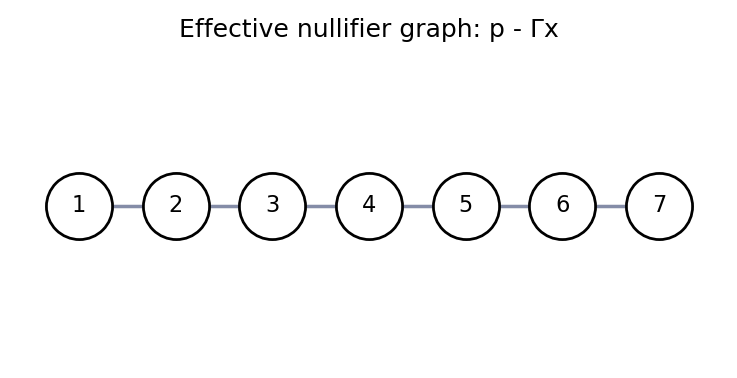

In [173]:
# Effective nullifier graph from V
V_xx = V[:m, :m]
V_xp = V[:m, m:]
V_px = V[m:, :m]
V_pp = V[m:, m:]

# nullfier 1 -> delta1 = p - Gamma1 x 꼴인 경우
Gamma1 = V_px @ np.linalg.pinv(V_xx)
Vd1 = V_pp - Gamma1 @ V_xp - V_px @ Gamma1.T + Gamma1 @ V_xx @ Gamma1.T


# nullfier 2 -> delta2 = x - Gamma2 p 꼴인 경우
Gamma2 = V_xp @ np.linalg.pinv(V_pp)
Vd2 = V_xx - Gamma2 @ V_px - V_xp @ Gamma2.T + Gamma2 @ V_pp @ Gamma2.T

# choose better nullifier
if np.trace(Vd1) <= np.trace(Vd2):
    Gamma_eff = Gamma1
    V_delta = Vd1
    nullifier_type = "p - Γx"
else:
    Gamma_eff = Gamma2
    V_delta = Vd2
    nullifier_type = "x - Γp"

nullifier_var = np.diag(V_delta)




print("chosen:", nullifier_type)
# nullifier variances 출력
print("nullifier variances =", nullifier_var)

# check nullifier variances below vacuum
print("below vacuum:", nullifier_var < 1)

# 해당 nullifer variances로 나온 effective adjacency matrix 출력
print("Adj_eff =\n", Gamma_eff)


# plot the graph using the graph plotting function defined above 
# plot_graph_from_matrix (W=Gamma_eff, node_values=kurtosis같은 노드별 값(기본은 none), title=f"(제목)", pos=pos(기본은 none))
pos = plot_graph_from_matrix(
    Gamma_eff,
    node_values=None,
    title=f"Effective nullifier graph: {nullifier_type}",
    pos=  
    {
    0: (0.0, 0.0),
    1: (1.5, 0.0),
    2: (3, 0.0),
    3: (4.5, 0.0),
    4: (6, 0.0),
    5: (7.5, 0.0),
    6: (9, 0.0),
    }
)

## 2. Photon Subtraction on the graph

##### A Matrix for Photon Subtraction

Pi_g projector check: True
A_minus symmetric check: True
A_minus = 


,1,2,3,4,5,6,7,8,9,10,11,12,13,14
1,8.950,0.000,0.000,0.000,0.000,0.000,0.000,0.000,9.945,0.000,0.000,0.000,0.000,0.000
2,0.000,11.050,0.000,0.000,0.000,0.000,0.000,10.055,0.000,11.050,0.000,0.000,0.000,0.000
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8,0.000,10.055,0.000,0.000,0.000,0.000,0.000,9.150,0.000,10.055,0.000,0.000,0.000,0.000
9,9.945,0.000,0.000,0.000,0.000,0.000,0.000,0.000,11.050,0.000,0.000,0.000,0.000,0.000
10,0.000,11.050,0.000,0.000,0.000,0.000,0.000,10.055,0.000,11.050,0.000,0.000,0.000,0.000


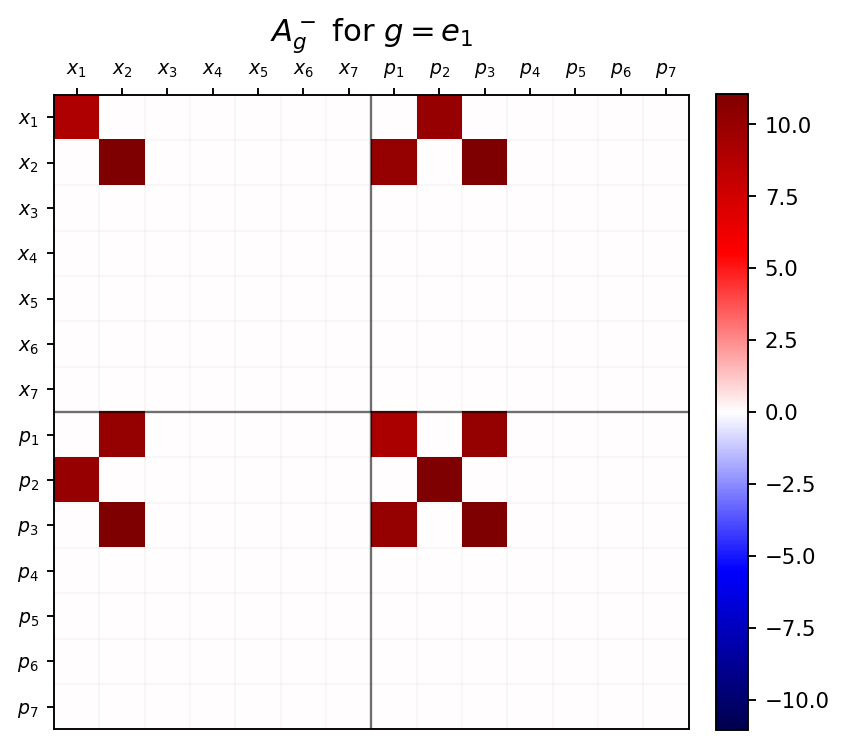

vmin=-11, vmax=11


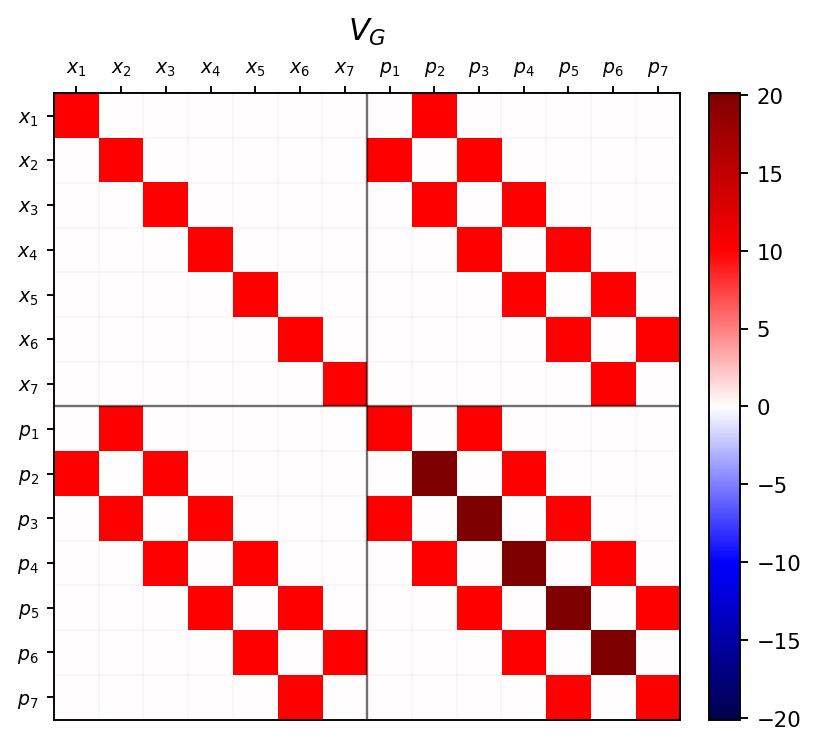

vmin=-20.1, vmax=20.1


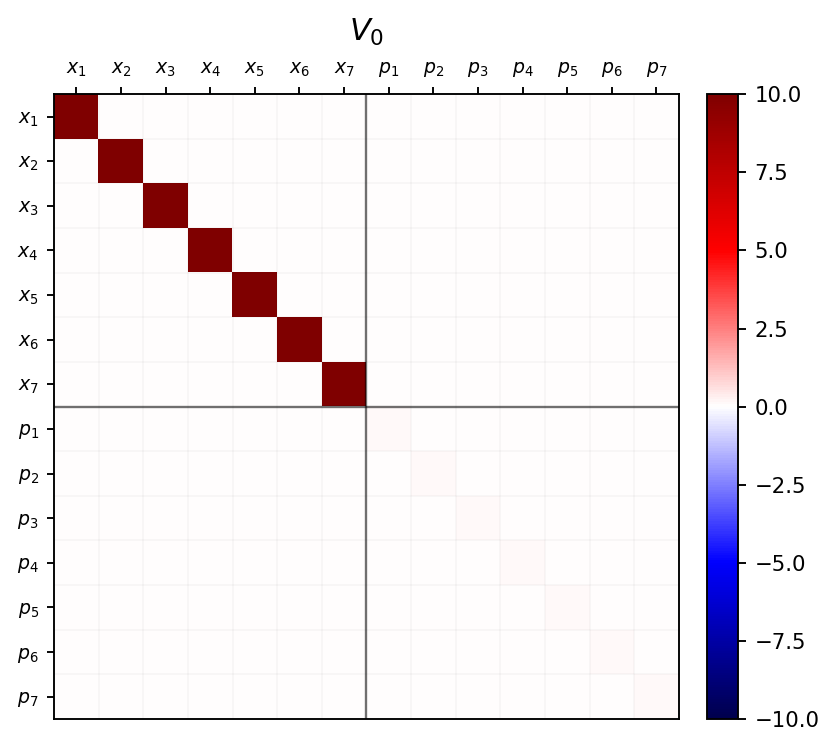

vmin=-10, vmax=10


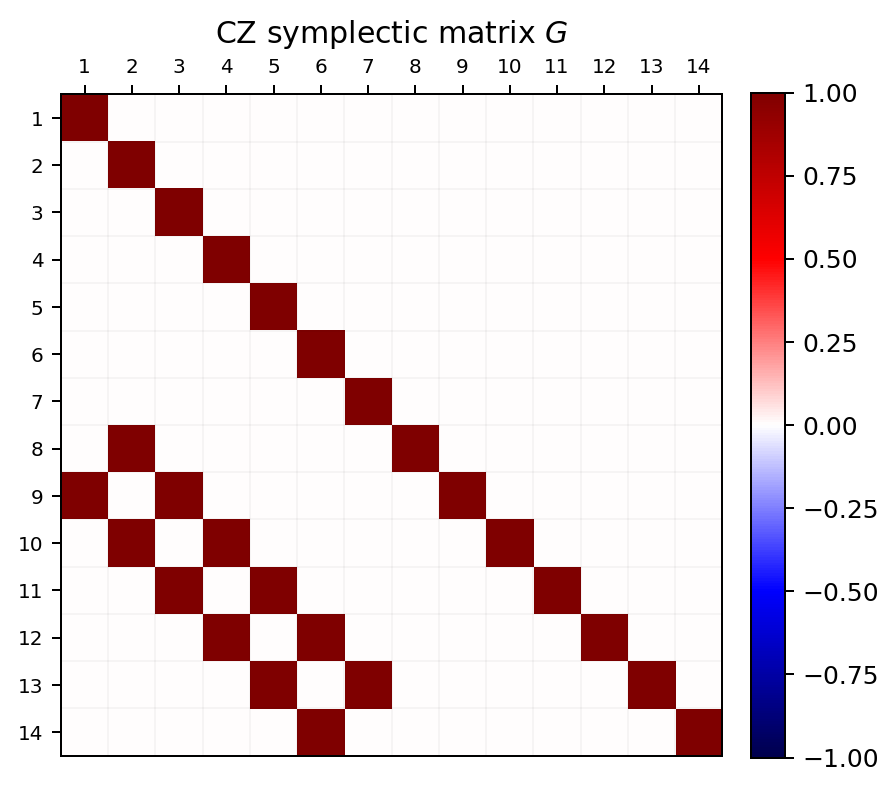

In [174]:
# A_minus matrix
# A_minus = 2 (V - I) Πg (V - I) / Tr[(V - I) Πg]

I_2m = np.eye(2 * m) # 2m x 2m identity matrix, m은 모드 수

denom = np.trace((V - I_2m) @ Pi_g) # 분모 계산, Tr[(V - I) Πg] , 이거의 4배값이 photon subtraction의 성공확률

# print("denom =", denom)
# 예외처리
if np.isclose(denom, 0):
    raise ValueError("denom is close to zero: photon subtraction mode may be vacuum-like.")

A_minus = 2 * (V - I_2m) @ Pi_g @ (V - I_2m) / denom

print("Pi_g projector check:", bool(np.linalg.norm(Pi_g @ Pi_g - Pi_g))<1e-10)
print("A_minus symmetric check:", bool(np.linalg.norm(A_minus - A_minus.T) < 1e-10))
#print("A_minus =\n", A_minus)
show_mat(A_minus, name="A_minus = ")

#draw_mat(A_minus, r"$A_g^-$")
draw_phase_matrix(
    A_minus,
    title = rf"$A_g^-$ for {sub_label}",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True,
    #vmax = 11, vmin = -11
)
draw_phase_matrix(
    V,
    title=r"$V_G$",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)
draw_phase_matrix(
    V0,
    title=r"$V_0$",
    positive=False,
    cmap="seismic",
    vmin = None,
    vmax = 10,
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)
draw_mat(G, title=r"CZ symplectic matrix $G$", cmap="seismic", label=False, digits=1,grid=True)

v_p = [10.1 20.1 20.1 20.1 20.1 20.1 10.1]
a_p = [ 9.15027624 11.04972376 11.04972376  0.          0.          0.
  0.        ]
K_ex_p = [-0.67782211 -0.37749891 -0.37749891 -0.         -0.         -0.
 -0.        ]


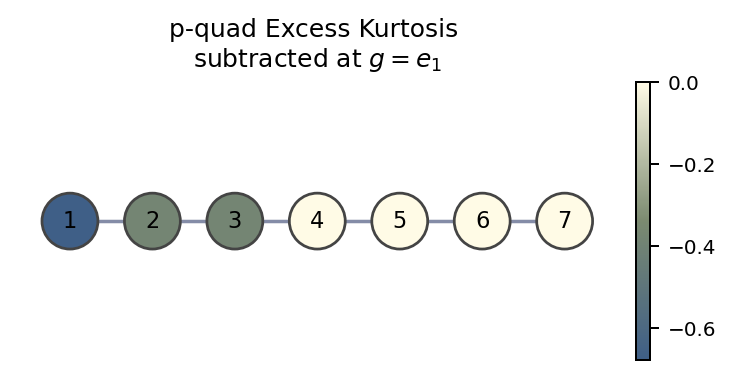

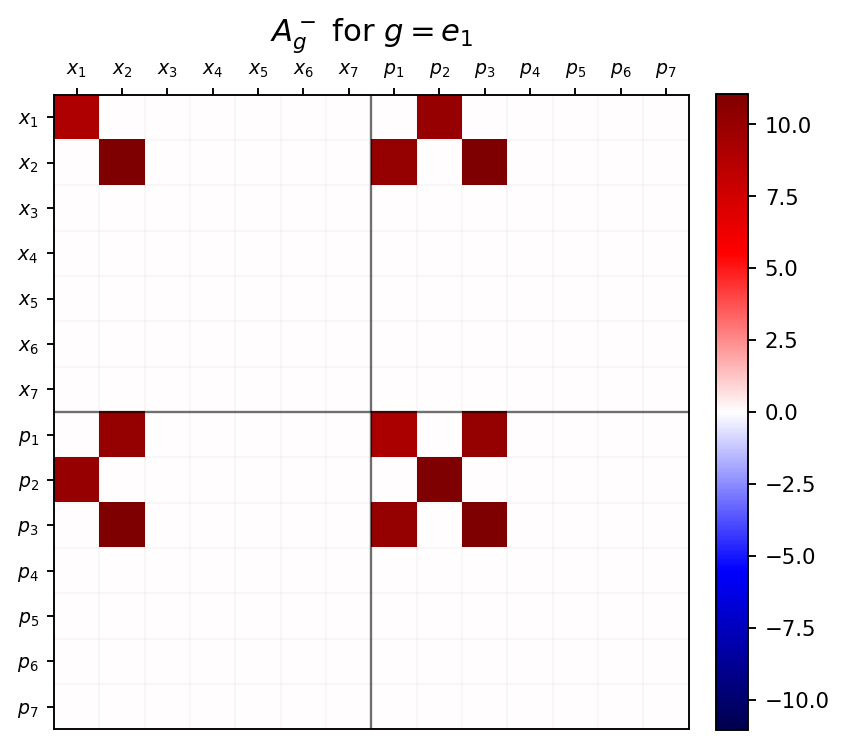

vmin=-11, vmax=11


In [175]:
# Node-wise p-quadrature excess kurtosis

p_indices = np.arange(m, 2 * m) # p-quadrature는 phase space 벡터의 뒤쪽 m개 요소에 해당하므로, 인덱스가 m부터 2m-1까지인 부분을 선택

v_p = np.diag(V)[p_indices] # photon subtraction 전의 p-quadrature variance, V 행렬의 뒤쪽 m개 대각 원소에 해당
a_p = np.diag(A_minus)[p_indices] # photon subtraction으로 인한 p-quadrature variance 변화량, A_minus 행렬의 뒤쪽 m개 대각 원소에 해당

K_ex_p = -3 * (a_p ** 2) / ((v_p + a_p) ** 2) # <Q(f)^k>_T를 통해 excess kurtosis p-quadrature 계산, 

print("v_p =", v_p)
print("a_p =", a_p)
print("K_ex_p =", K_ex_p)

pos = plot_graph_from_matrix(
    Gamma_eff,
    node_values=K_ex_p,
    title=f"p-quad Excess Kurtosis \nsubtracted at {sub_label}",
    pos=pos,
    draw_labels=True,
    vmax=-0.0, vmin=-0.6778221137904276
)

draw_phase_matrix(
    A_minus,
    title = rf"$A_g^-$ for {sub_label}",
    positive=False,
    cmap="seismic",
    tick_step=1,
    figsize=(5, 4.5),
    grid=True
)


##### Additional Analysis - Wigner negativity

In [176]:
def reduced_matrices(V, A, subset, m):
    """
    V, A: full 2m x 2m matrices
    subset: list of mode indices,
            e.g. [1] for node 1, [1, 3, 6] for nodes 1,3,6
    m: number of modes
    """
    subset = np.array(subset, dtype=int)-1

    inds = np.concatenate([subset, m + subset])

    V_sub = V[np.ix_(inds, inds)]
    A_sub = A[np.ix_(inds, inds)]

    return V_sub, A_sub, inds

In [177]:
V_k, A_k, inds = reduced_matrices(V, A_minus, subset=[1,3,6], m=m) # node 1에 해당하는 mode만 남긴 reduced matrix, subset=[1]은 node 1을 의미, m은 전체 모드 수

show_mat(V_k)
show_mat(A_k)

M


,1,2,3,4,5,6
1,10.000,0.000,0.000,0.000,0.000,0.000
2,0.000,10.000,0.000,0.000,0.000,0.000
3,0.000,0.000,10.000,0.000,0.000,0.000
4,0.000,0.000,0.000,10.100,10.000,0.000
5,0.000,0.000,0.000,10.000,20.100,0.000
6,0.000,0.000,0.000,0.000,0.000,20.100


M


,1,2,3,4,5,6
1,8.950,0.000,0.000,0.000,0.000,0.000
2,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,9.150,10.055,0.000
5,0.000,0.000,0.000,10.055,11.050,0.000
6,0.000,0.000,0.000,0.000,0.000,0.000


In [178]:
def nodewise_negativity_quantities(V, A, m):
    N_vals = np.zeros(m)   # N_k = Tr(V_k^{-1} A_k)
    W0_vals = np.zeros(m)  # W_k(0)

    for k in range(1, m + 1):   # 1-indexed node label
        V_k, A_k, _ = reduced_matrices(V, A, [k], m)

        N_k = np.trace(np.linalg.inv(V_k) @ A_k)
        W0_k = (2 - N_k) / (2 * (2 * np.pi) * np.sqrt(np.linalg.det(V_k)))

        N_vals[k - 1] = N_k
        W0_vals[k - 1] = W0_k

    return N_vals, W0_vals

min W0_vals = 0.0015757677038904002


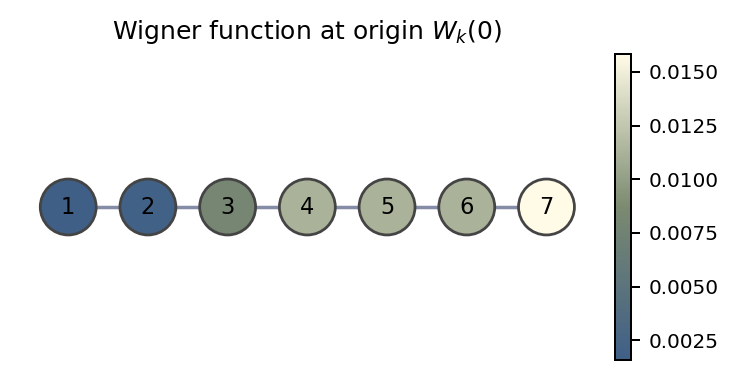

In [179]:
N_vals, W0_vals = nodewise_negativity_quantities(V, A_minus, m)

#print("N_vals =", N_vals)
#print("W0_vals =", W0_vals)
print("min W0_vals =", np.min(W0_vals))
# plot_graph_from_matrix(
#     Adj,
#     node_values=W0_vals,
#     title="Wigner function at origin $W_k(0)$",
#     pos=pos,
#     cmap="nipy_spectral", 
#     vmin=np.min(W0_vals),
#     draw_labels=True
# )



pos = plot_graph_from_matrix(
    Adj,
    node_values=W0_vals,
    title="Wigner function at origin $W_k(0)$",
    pos=pos,
    draw_labels=True
)

In [180]:
def nodewise_gaussian_wigner_origin(V, m):
    WG0 = np.zeros(m)

    for k in range(1, m + 1):
        V_k, _, _ = reduced_matrices(V, np.zeros_like(V), subset=[k], m=m)
        WG0[k - 1] = 1 / ((2 * np.pi) * np.sqrt(np.linalg.det(V_k)))

    return WG0

##### Ploting Wigner function

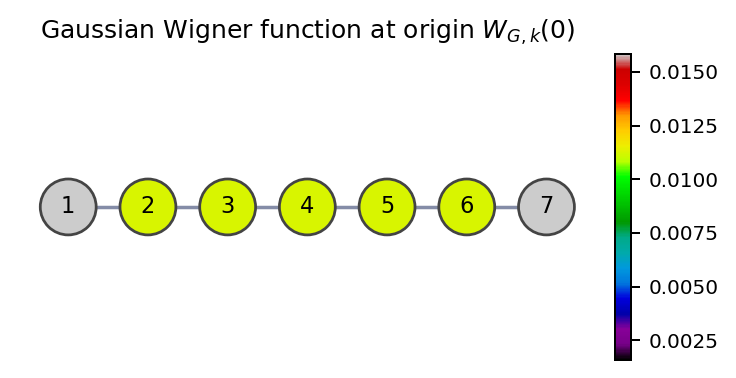

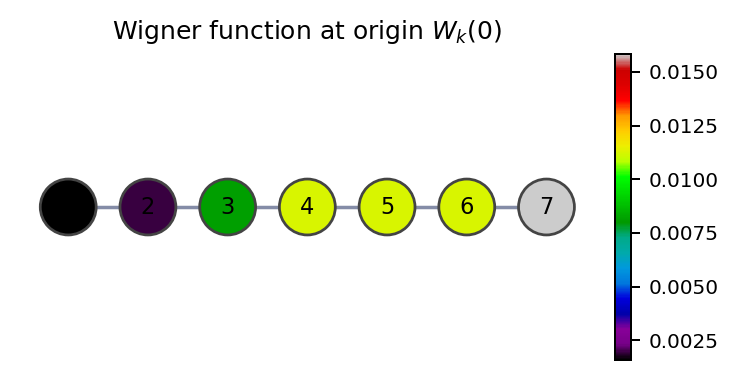

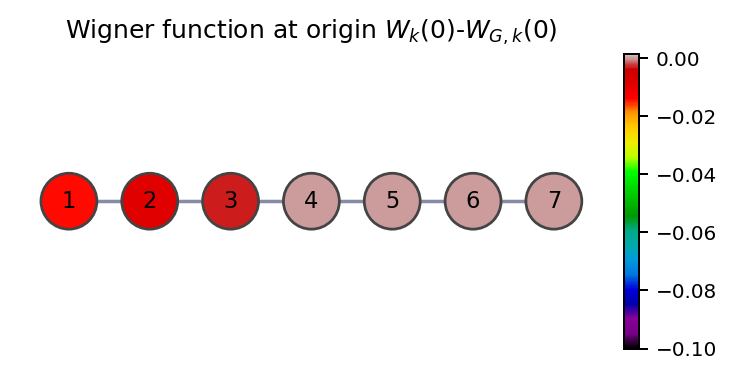

{0: (0.0, 0.0),
 1: (1.5, 0.0),
 2: (3, 0.0),
 3: (4.5, 0.0),
 4: (6, 0.0),
 5: (7.5, 0.0),
 6: (9, 0.0)}

In [181]:
WG0_vals = nodewise_gaussian_wigner_origin(V, m)

pos = plot_graph_from_matrix(
    Adj,
    node_values=WG0_vals,
    cmap="nipy_spectral",
    pos=pos,
    draw_labels=True,
    vmin=np.min(W0_vals),
    title=r"Gaussian Wigner function at origin $W_{G,k}(0)$"
)
plot_graph_from_matrix(
    Adj,
    node_values=W0_vals,
    title="Wigner function at origin $W_k(0)$",
    pos=pos,
    cmap="nipy_spectral", 
    vmin=np.min(W0_vals),
    draw_labels=True
)
plot_graph_from_matrix(
    Adj,
    node_values=W0_vals-WG0_vals,
    title="Wigner function at origin $W_k(0)$-$W_{G,k}(0)$",
    pos=pos,
    cmap="nipy_spectral", 
    vmin=np.min(W0_vals),
    draw_labels=True
)

In [182]:
# Common Wigner plotting utilities.
# Run this cell once, then use the output cell below.

from matplotlib.colors import Normalize, TwoSlopeNorm
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Gaussian Wigner function을 그리기 위해 범위를 지정하고, Gaussian Wigner function 값 계산
def gaussian_wigner_grid(V_k, xlim=10, n=100):
    x = np.linspace(-xlim, xlim, n)
    p = np.linspace(-xlim, xlim, n)
    X, P = np.meshgrid(x, p)
    R = np.stack([X, P], axis=-1)

    V_inv = np.linalg.inv(V_k)
    det_V = np.linalg.det(V_k)
    quad = np.einsum("...i,ij,...j->...", R, V_inv, R)
    W = np.exp(-0.5 * quad) / ((2 * np.pi) * np.sqrt(det_V))

    return X, P, W

# Photon-subtracted Wigner function을 그리기 범위를 지정하고 Photon-subtracted Wigner function 값 계산
def photon_subtracted_wigner_grid(V_k, A_k, xlim=10, n=100):
    X, P, W_gauss = gaussian_wigner_grid(V_k, xlim=xlim, n=n)
    R = np.stack([X, P], axis=-1)

    V_inv = np.linalg.inv(V_k)
    B = V_inv @ A_k @ V_inv
    quad_A = np.einsum("...i,ij,...j->...", R, B, R)
    trace_A = np.trace(V_inv @ A_k)
    W_minus = 0.5 * (quad_A - trace_A + 2) * W_gauss

    return X, P, W_minus

# 앞에서 구한 V와 A_minus 행렬을 single node로 reduce한 후, 해당 x,p,W를 위의 함수로 구한 후 위에서 지정한 범위내에서 최대, 최소를 계산하여 zlim으로 반환하는 함수
def node_wigner_data(V, A, node, m, xlim=10, n=100):
    V_k, A_k, _ = reduced_matrices(V, A, subset=[node], m=m)
    X, P, W_before = gaussian_wigner_grid(V_k, xlim=xlim, n=n)
    _, _, W_after = photon_subtracted_wigner_grid(V_k, A_k, xlim=xlim, n=n)

    z_min = min(np.min(W_before), np.min(W_after))
    z_max = max(np.max(W_before), np.max(W_after))
    z_pad = 0.05 * (z_max - z_min) if not np.isclose(z_min, z_max) else 1e-3
    zlim = (z_min - z_pad, z_max + z_pad)

    return X, P, W_before, W_after, zlim

# Wigner function의 색상 범위를 W의 최소값과 최대값에 따라 자동으로 조절하는 norm 객체를 반환하는 함수, TwoSlopeNorm은 W가 음수와 양수 모두를 포함할 때 0을 중심으로 색상을 조절하는 데 사용되고, Normalize는 W가 모두 양수이거나 모두 음수일 때 사용된다.
# TwoSlopeNorm가 하는 일은 양수일 때와 음수일 때 색상이 다른 그라데이션, Normalize는 양수이거나 음수일 때 중심값 기준으로 다른 그라데이션이 되게 설정해줌
def wigner_color_norm(W):
    w_min = np.min(W)
    w_max = np.max(W)

    if w_min < 0 < w_max:
        return TwoSlopeNorm(vmin=w_min, vcenter=0, vmax=w_max)

    return Normalize(vmin=w_min, vmax=w_max)

# Wigner function을 3D surface plot으로 그리는 함수, zero_plane이 True이면 W=0인 평면도 같이 그려준다.
# 함수 설명 ax: 3D plot이 그려질 matplotlib 축 객체, ax.plot_surface라는 메소드는 3D surface plot을 그리는 메소드이며, ax.countour는 등고선을 그리는 메소드이다. 
# 나중에 plt.figure로 figure 객체를 만들고, fig.add_subplot(1, 2, 1, projection="3d")같이 3D 축 객체를 따로 정의해서 만들고 이 함수를 호출하면 된다.
# 이후 이 객체(3D_subfigure)에 대해서 제목, 축 레이블, 시점 등을 설정할 수 있다. set_zlim은 혹여나 W의 범위가 너무 크거나 작아서 그래프가 잘 안보이는 경우 z축 범위를 수동으로 설정할 때 사용한다.

def plot_wigner_surface_static(ax, X, P, W, title, cmap="inferno", zlim=None, zero_plane=True):
    norm = wigner_color_norm(W)
    ax.plot_surface(X, P, W, cmap=cmap, norm=norm, linewidth=0, antialiased=True)

    if zero_plane and zlim is not None and zlim[0] < 0 < zlim[1]:
        Z0 = np.zeros_like(W)
        ax.plot_surface(X, P, Z0, color="black", alpha=0.12, linewidth=0, shade=False)
        ax.contour(X, P, W, levels=[0], zdir="z", offset=0, colors="black", linewidths=1.1)

    ax.contour(X, P, W, zdir="z", offset=np.min(W), cmap=cmap, linewidths=0.7)
    ax.set_title(f"{title}\nmin={np.min(W):.3g}, max={np.max(W):.3g}")
    ax.set_xlabel("x")
    ax.set_ylabel("p")
    ax.set_zlabel("W")
    ax.view_init(elev=24, azim=-38) # 시점 설정, elev은 z축에 대한 높이, azim은 x축에 대한 회전 각도

    if zlim is not None:
        ax.set_zlim(*zlim)


# 위에서 wigner_surface를 matplotlib으로는 그리는 함수를 호출하는 함수이다. 이때 figure안에 두 sub 객체를 만들어 왼쪽은 Gaussian Wigner function, 오른쪽은 photon-subtracted Wigner function이 그려지게 된다. 
# cmap_before와 cmap_after는 각각 Gaussian Wigner function과 photon-subtracted Wigner function의 색상 맵을 지정하는 인자이다. (가우시안은 항상 양수이니 viridis, photon-subtracted는 양수/음수 모두 나올 수 있으니 coolwarm같은 colormap을 사용)


def plot_node_wigner_3d_static(V, A, node, m, xlim=10, n=100, cmap_before="viridis", cmap_after="coolwarm"):
    X, P, W_before, W_after, zlim = node_wigner_data(V, A, node, m, xlim=xlim, n=n)

    fig = plt.figure(figsize=(14, 5.2))
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    plot_wigner_surface_static(ax1, X, P, W_before, f"node {node}: before subtraction", cmap=cmap_before, zlim=zlim, zero_plane=False)
    plot_wigner_surface_static(ax2, X, P, W_after, f"node {node}: after subtraction", cmap=cmap_after, zlim=zlim)

    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.88, wspace=0.04)
    plt.show()

# 위와는 다르게 정적이지 않고 직접 그래프를 회전 시키면서 볼 수 있게 plotly로 그리는 함수이다.
# plotly의 make_subplots 함수를 사용하여 figure 안에 2개의 subplot을 만들고, 각각에 go.Surface를 사용하여 Wigner function의 surface plot을 그린다.(기본 작동원리는 matplotlib처럼 x,y,z축 데이터를 받아 그림)
# 차이점은 figure객체를 정의하는 방식과 plot_surface 대신 go.Surface를 사용한다는 점이다.(go.Surface는 plotly에서 3D surface plot을 그리는 메소드이다.)
# 자세한건 plotly 공식문서의 go.Surface와 make_subplots 설명 참고: https://plotly.com/python/3d-surface-plots/ , https://plotly.com/python/subplots/
def plot_node_wigner_3d_interactive(V, A, node, m, xlim=10, n=100):
    X, P, W_before, W_after, _ = node_wigner_data(V, A, node, m, xlim=xlim, n=n)

    after_abs = max(abs(np.min(W_after)), abs(np.max(W_after)))
    if np.isclose(after_abs, 0):
        after_abs = 1

    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{"type": "surface"}, {"type": "surface"}]],
        subplot_titles=(
            f"node {node}: before subtraction<br>min={np.min(W_before):.3g}, max={np.max(W_before):.3g}",
            f"node {node}: after subtraction<br>min={np.min(W_after):.3g}, max={np.max(W_after):.3g}"
        ),
        horizontal_spacing=0.02
    )

    fig.add_trace(
        go.Surface(x=X, y=P, z=W_before, colorscale="Viridis", showscale=False),
        row=1,
        col=1
    )

    fig.add_trace(
        go.Surface(
            x=X,
            y=P,
            z=W_after,
            colorscale="RdBu_r",
            cmin=-after_abs,
            cmax=after_abs,
            showscale=True,
            colorbar=dict(title="W", x=1.02, len=0.75)
        ),
        row=1,
        col=2
    )

    fig.add_trace(
        go.Surface(
            x=X,
            y=P,
            z=np.zeros_like(W_after),
            surfacecolor=np.zeros_like(W_after),
            colorscale=[[0, "black"], [1, "black"]],
            opacity=0.18,
            showscale=False,
            hoverinfo="skip"
        ),
        row=1,
        col=2
    )

    camera = dict(eye=dict(x=0.8, y=1.8, z=0.8))
    scene_style = dict(
        xaxis_title="x",
        yaxis_title="p",
        zaxis_title="W",
        camera=camera,
        aspectmode="cube"
    )

    fig.update_layout(
        width=1150,
        height=560,
        margin=dict(l=0, r=0, t=60, b=0),
        scene=scene_style,
        scene2=scene_style
    )

    fig.show()


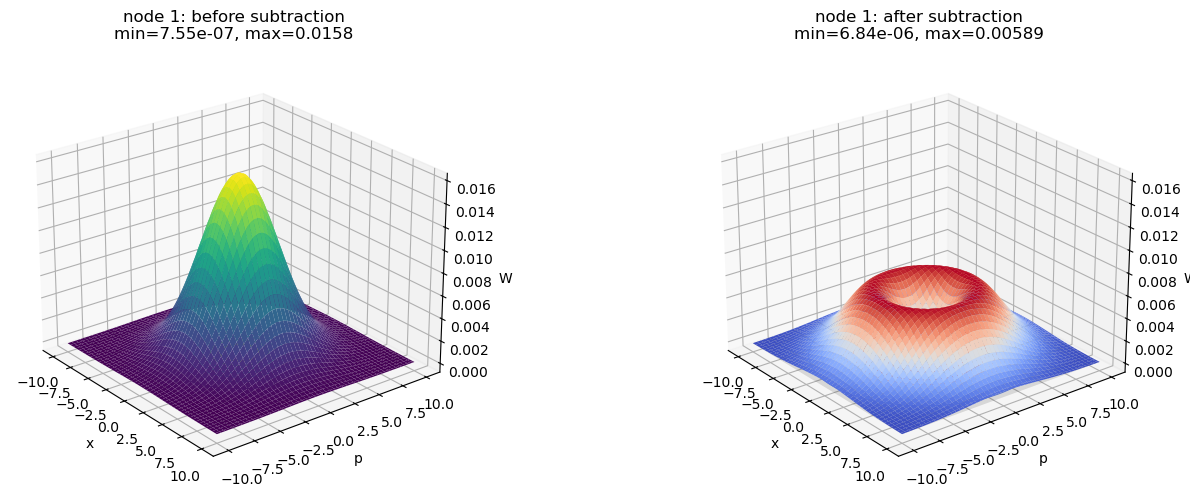

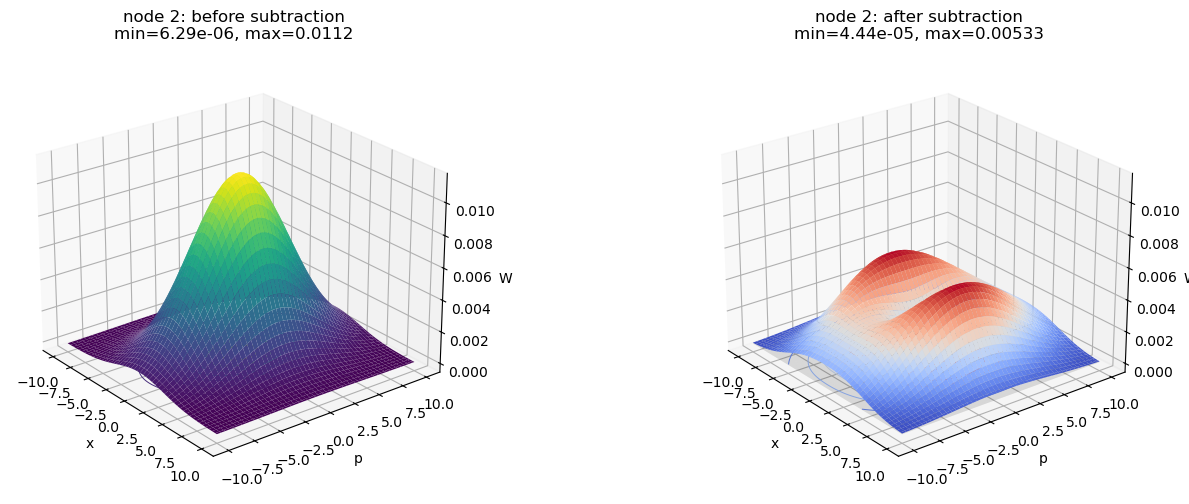

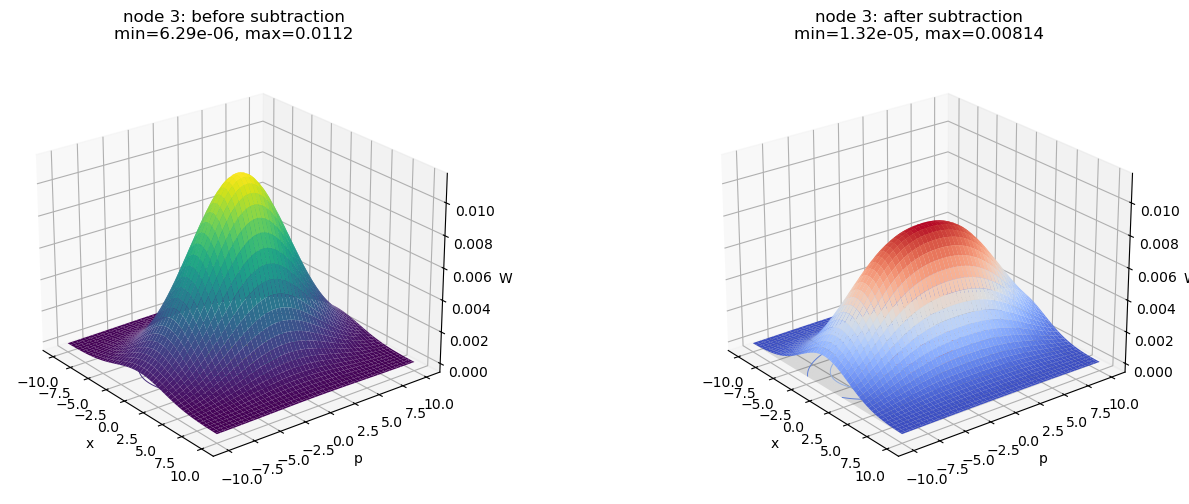

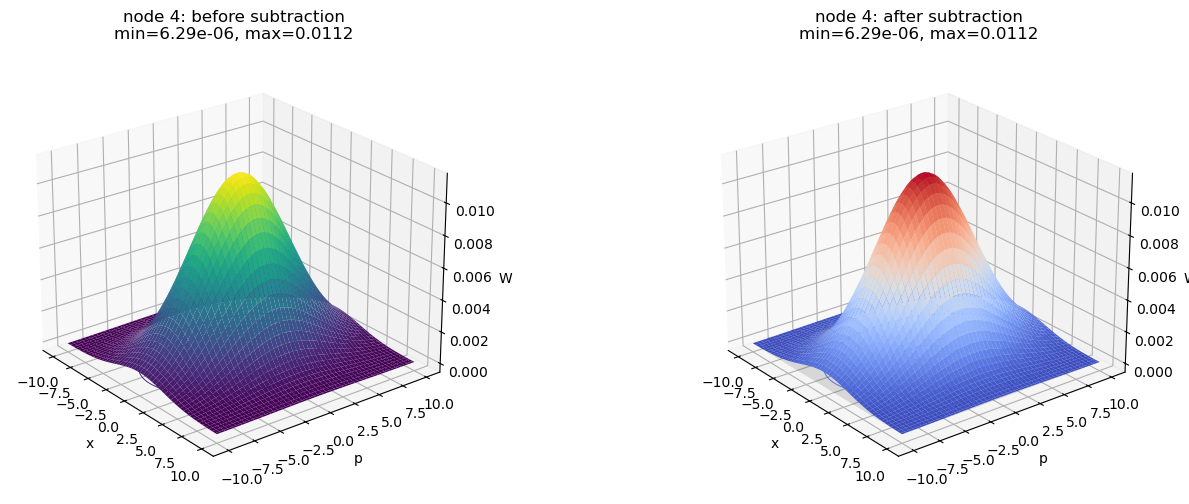

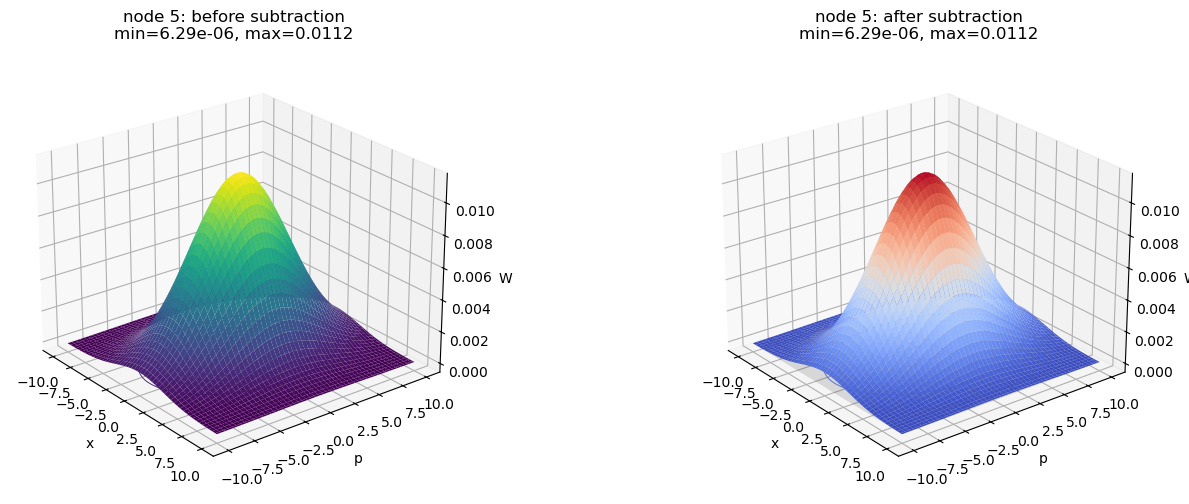

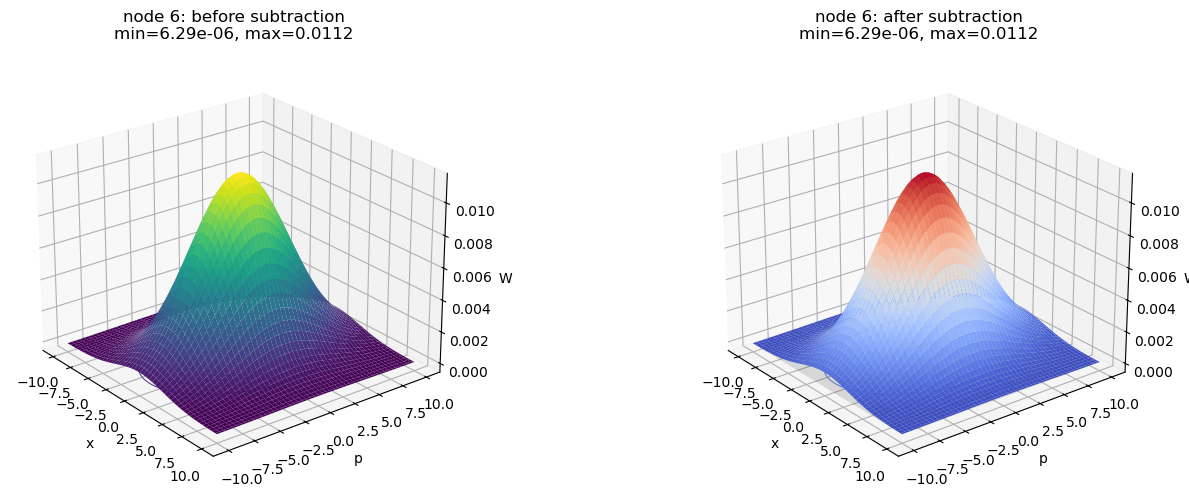

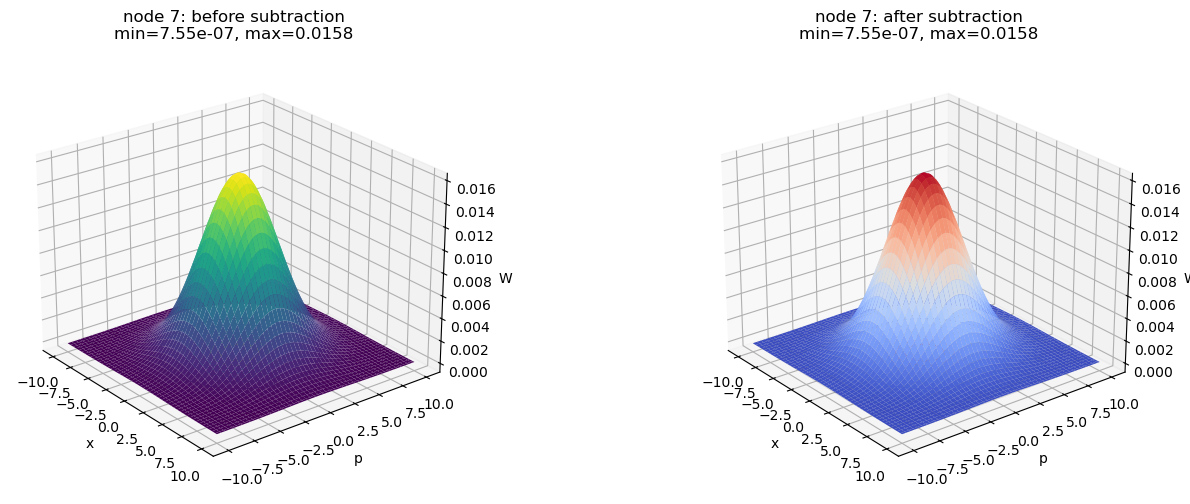

In [186]:

# 1부터 m까지의 노드에 대해, plot_static이 True이면 정적 3D plot을 그리고, plot_interactive이 True이면 인터랙티브 3D plot을 그린다. 
nodes_to_plot = range(1, m + 1)
plot_static = True
plot_interactive = False#True

# 노드별로 그리기 위해서 다음과 같이 정의
for node in nodes_to_plot:
    if plot_static:
        plot_node_wigner_3d_static(V, A_minus, node=node, m=m, xlim=10, n=100)

    if plot_interactive:
        plot_node_wigner_3d_interactive(V, A_minus, node=node, m=m, xlim=10, n=100)
